# Setup

In [ ]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Section 1: Dataset structure & loading

### Section 1.1: Imports

In [1]:
from transformers import AutoTokenizer
from huggingface_hub import login
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import nltk
from collections import Counter
import string
from wordcloud import WordCloud
from rouge_score import rouge_scorer

### Section 1.2: Dataset loading

In [2]:
base_path = os.getcwd()
data_roots = [
    'multiclinsum_gs_train_en',
    'multiclinsum_large-scale_train_en',
    'multiclinsum_test_en'
]

dfs = {}

for folder in data_roots:
    fulltext_dir = os.path.join(base_path, 'Data', folder, 'fulltext')
    summary_dir = os.path.join(base_path, 'Data', folder, 'summaries')
    folder_data = []

    for file_name in os.listdir(fulltext_dir):
        if file_name.endswith('.txt'):
            path_ft = os.path.join(fulltext_dir, file_name)
            summary_name = file_name.replace('.txt', '_sum.txt')
            path_sm = os.path.join(summary_dir, summary_name)

            with open(path_ft, 'r', encoding='utf-8') as f:
                full_text = f.read()
            with open(path_sm, 'r', encoding='utf-8') as s:
                summary_text = s.read()

            folder_data.append({
                'Full_Text': full_text,
                'Summary': summary_text
            })

    dfs[folder] = pd.DataFrame(folder_data)

df_gs = dfs['multiclinsum_gs_train_en']
df_large = dfs['multiclinsum_large-scale_train_en']
df_test = dfs['multiclinsum_test_en']

### Section 1.3: Row count verification

In [3]:
print(f"Gold-standard training dataset row count: {df_gs.shape[0]}/592")
print(f"Large scale training dataset row count: {df_large.shape[0]}/25902")
print(f"Test dataset row count: {df_test.shape[0]}/3396")

Gold-standard training dataset row count: 592/592
Large scale training dataset row count: 25902/25902
Test dataset row count: 3396/3396


### Section 1.4: Data preview

In [4]:
df_gs.head(3)

,Full_Text,Summary
0,The authors present the case of a 49-year-old ...,The authors report a rare case of use of Advan...
1,29-year-old female patient with a history of f...,29-year-old male presented to the emergency de...
2,"Object\nThe patient, a 37-year-old woman, was ...",A 37-year-old woman wheelchair-bound was diagn...


In [5]:
df_large.head(3)

,Full_Text,Summary
0,A 29-year-old male developed right testicular ...,A 29-year-old man presented to our emergency d...
1,A 45-year-old Chinese man had elevated blood p...,We report the case of a 45-year-old Chinese ma...
2,"A 78-year-old Caucasian man, with a history of...",A rare case of eosinophilic pneumonia occurrin...


In [6]:
df_test.head(3)

,Full_Text,Summary
0,A 29-year-old black Cameroonian of Bamileke et...,We report a case of a ruptured caesarean scar ...
1,A 61-year-old white woman with an unremarkable...,A 61-year-old woman of European descent was re...
2,A 46-year-old man presented with generalized s...,A 46-year-old man developed hypertensive encep...


# Section 2: Basic corpus statistics

### Section 2.1: Data integrity check

In [7]:
print(f"Gold-standard training dataset NaN count: {df_gs.isnull().sum().sum()}")
print(f"Large scale training dataset NaN count: {df_large.isnull().sum().sum()}")
print(f"Test dataset NaN count: {df_test.isnull().sum().sum()}")

Gold-standard training dataset NaN count: 0
Large scale training dataset NaN count: 0
Test dataset NaN count: 0


In [8]:
print(f"Gold-standard training dataset empty strings: {(df_gs == '').sum().sum()}")
print(f"Large scale training dataset empty strings: {(df_large == '').sum().sum()}")
print(f"Test dataset empty strings: {(df_test == '').sum().sum()}")

Gold-standard training dataset empty strings: 0
Large scale training dataset empty strings: 0
Test dataset empty strings: 0


In [9]:
print(f"Gold-standard training dataset duplicates: {df_gs.duplicated().sum()}")
print(f"Large scale training dataset duplicates: {df_large.duplicated().sum()}")
print(f"Test dataset duplicates: {df_test.duplicated().sum()}")

Gold-standard training dataset duplicates: 0
Large scale training dataset duplicates: 0
Test dataset duplicates: 0


### Section 2.2: Word & character count statistics

In [10]:
df_gs["Full_Text_Char_Count"] = df_gs["Full_Text"].str.len()
df_gs["Summary_Char_Count"] = df_gs["Summary"].str.len()
df_large["Full_Text_Char_Count"] = df_large["Full_Text"].str.len()
df_large["Summary_Char_Count"] = df_large["Summary"].str.len()
df_test["Full_Text_Char_Count"] = df_test["Full_Text"].str.len()
df_test["Summary_Char_Count"] = df_test["Summary"].str.len()

df_gs["Full_Text_Word_Count"] = df_gs["Full_Text"].apply(lambda row: len(row.split()))
df_gs["Summary_Word_Count"] = df_gs["Summary"].apply(lambda row: len(row.split()))
df_large["Full_Text_Word_Count"] = df_large["Full_Text"].apply(lambda row: len(row.split()))
df_large["Summary_Word_Count"] = df_large["Summary"].apply(lambda row: len(row.split()))
df_test["Full_Text_Word_Count"] = df_test["Full_Text"].apply(lambda row: len(row.split()))
df_test["Summary_Word_Count"] = df_test["Summary"].apply(lambda row: len(row.split()))


In [11]:
df_gs.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,592.000000,592.000000,592.000000,592.000000
mean,3785.868243,725.721284,561.652027,103.991554
std,2546.026522,325.461539,373.230431,47.566944
min,720.000000,91.000000,104.000000,14.000000
25%,2551.250000,510.500000,376.000000,73.000000
50%,3349.500000,676.000000,493.500000,96.500000
75%,4587.000000,875.250000,683.250000,126.000000
max,34072.000000,3884.000000,5275.000000,581.000000


In [12]:
df_large.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,25902.000000,25902.000000,25902.000000,25902.000000
mean,3529.722068,675.301753,532.160798,97.189406
std,1590.773624,317.884833,238.947424,45.780361
min,569.000000,100.000000,97.000000,20.000000
25%,2378.000000,438.000000,360.000000,63.000000
50%,3257.000000,629.000000,490.000000,90.000000
75%,4359.000000,865.000000,657.750000,125.000000
max,10713.000000,2157.000000,1598.000000,310.000000


In [13]:
df_test.describe()

,Full_Text_Char_Count,Summary_Char_Count,Full_Text_Word_Count,Summary_Word_Count
count,3396.000000,3396.000000,3396.000000,3396.000000
mean,3533.808893,681.846879,532.305948,98.108657
std,1648.559086,318.456715,251.887483,46.139070
min,705.000000,121.000000,104.000000,20.000000
25%,2401.000000,451.000000,359.000000,65.000000
50%,3220.000000,633.000000,483.000000,90.000000
75%,4394.000000,874.000000,658.000000,126.000000
max,25824.000000,3944.000000,4862.000000,637.000000


### Section 2.3: Full text vs summary length comparison

In [14]:
df_gs["Compression_Rate"] = df_gs["Summary_Word_Count"] / df_gs["Full_Text_Word_Count"]
df_large["Compression_Rate"] = df_large["Summary_Word_Count"] / df_large["Full_Text_Word_Count"]
df_test["Compression_Rate"] = df_test["Summary_Word_Count"] / df_test["Full_Text_Word_Count"]

print(f"Gold-standard training dataset mean compression rate: {df_gs["Compression_Rate"].mean().round(2)}")
print(f"Large scale training dataset mean compression rate: {df_large["Compression_Rate"].mean().round(2)}")
print(f"Test dataset mean compression rate: {df_test["Compression_Rate"].mean().round(2)}")

Gold-standard training dataset mean compression rate: 0.23
Large scale training dataset mean compression rate: 0.21
Test dataset mean compression rate: 0.22


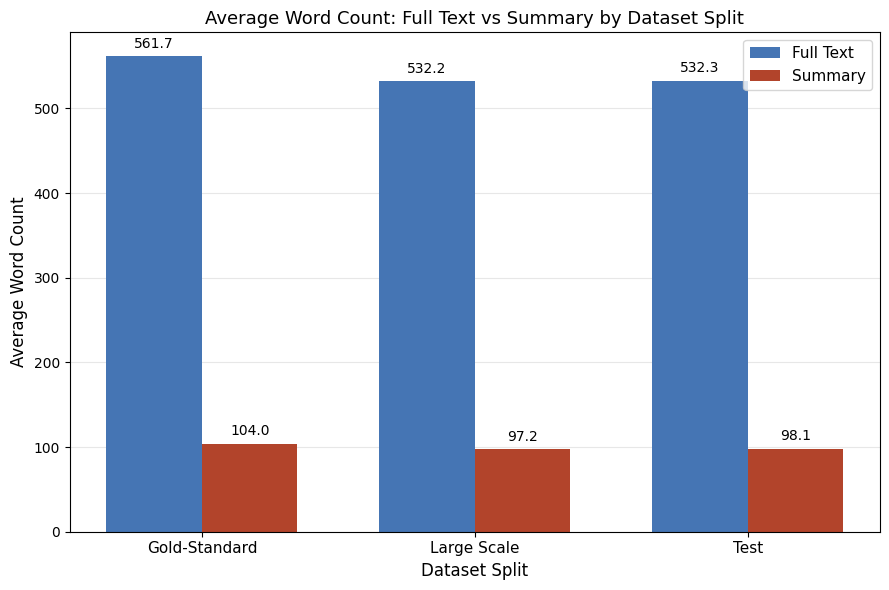

In [15]:
splits = ['Gold-Standard', 'Large Scale', 'Test']

avg_fulltext = [
    df_gs['Full_Text_Word_Count'].mean(),
    df_large['Full_Text_Word_Count'].mean(),
    df_test['Full_Text_Word_Count'].mean()
]

avg_summary = [
    df_gs['Summary_Word_Count'].mean(),
    df_large['Summary_Word_Count'].mean(),
    df_test['Summary_Word_Count'].mean()
]

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(x - width/2, avg_fulltext, width, label='Full Text', color='#4575B4')
bars2 = ax.bar(x + width/2, avg_summary, width, label='Summary', color='#B2442B')

ax.bar_label(bars1, fmt='%.1f', padding=4, fontsize=10)
ax.bar_label(bars2, fmt='%.1f', padding=4, fontsize=10)

ax.set_xlabel('Dataset Split', fontsize=12)
ax.set_ylabel('Average Word Count', fontsize=12)
ax.set_title('Average Word Count: Full Text vs Summary by Dataset Split', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [16]:
print(f"Gold-standard summaries longer than full text: {df_gs[df_gs['Summary_Word_Count'] > df_gs['Full_Text_Word_Count']].shape[0]}")
print(f"Large scale summaries longer than full text: {df_large[df_large['Summary_Word_Count'] > df_large['Full_Text_Word_Count']].shape[0]}")
print(f"Test summaries longer than full text: {df_test[df_test['Summary_Word_Count'] > df_test['Full_Text_Word_Count']].shape[0]}")

Gold-standard summaries longer than full text: 2
Large scale summaries longer than full text: 0
Test summaries longer than full text: 1


# Section 3: In-depth corpus analysis

### Section 3.1: Token length distribution for the Llama 3.1 model

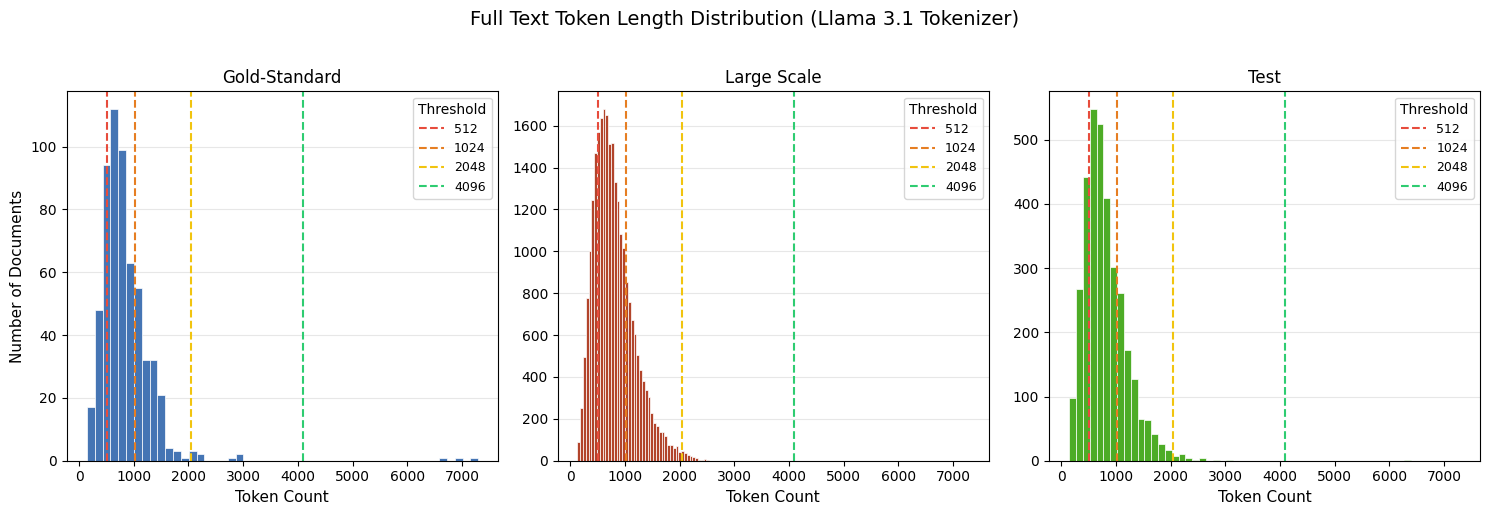


Gold-Standard
  >  512 tokens: 80.2% of documents
  > 1024 tokens: 25.5% of documents
  > 2048 tokens: 1.5% of documents
  > 4096 tokens: 0.5% of documents

Large-Scale
  >  512 tokens: 77.1% of documents
  > 1024 tokens: 23.0% of documents
  > 2048 tokens: 0.6% of documents
  > 4096 tokens: 0.0% of documents

Test
  >  512 tokens: 77.1% of documents
  > 1024 tokens: 23.6% of documents
  > 2048 tokens: 0.9% of documents
  > 4096 tokens: 0.0% of documents


In [17]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B")

df_gs["Token_Count"] = df_gs["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))
df_large["Token_Count"] = df_large["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))
df_test["Token_Count"] = df_test["Full_Text"].apply(lambda x: len(tokenizer.encode(x)))

thresholds = [512, 1024, 2048, 4096]
threshold_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in zip(axes, datasets):
    ax.hist(df["Token_Count"], bins=50, color=color, edgecolor='white', linewidth=0.5)
    for thresh, tcol in zip(thresholds, threshold_colors):
        ax.axvline(thresh, color=tcol, linestyle='--', linewidth=1.5, label=str(thresh))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Token Count", fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(title="Threshold", fontsize=9)

axes[0].set_ylabel("Number of Documents", fontsize=11)
fig.suptitle("Full Text Token Length Distribution (Llama 3.1 Tokenizer)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

for df, name in [(df_gs, "Gold-Standard"), (df_large, "Large-Scale"), (df_test, "Test")]:
    print(f"\n{name}")
    for thresh in thresholds:
        pct = (df["Token_Count"] > thresh).mean() * 100
        print(f"  > {thresh:>4} tokens: {pct:.1f}% of documents")

### Section 3.2: Compression rate distribution

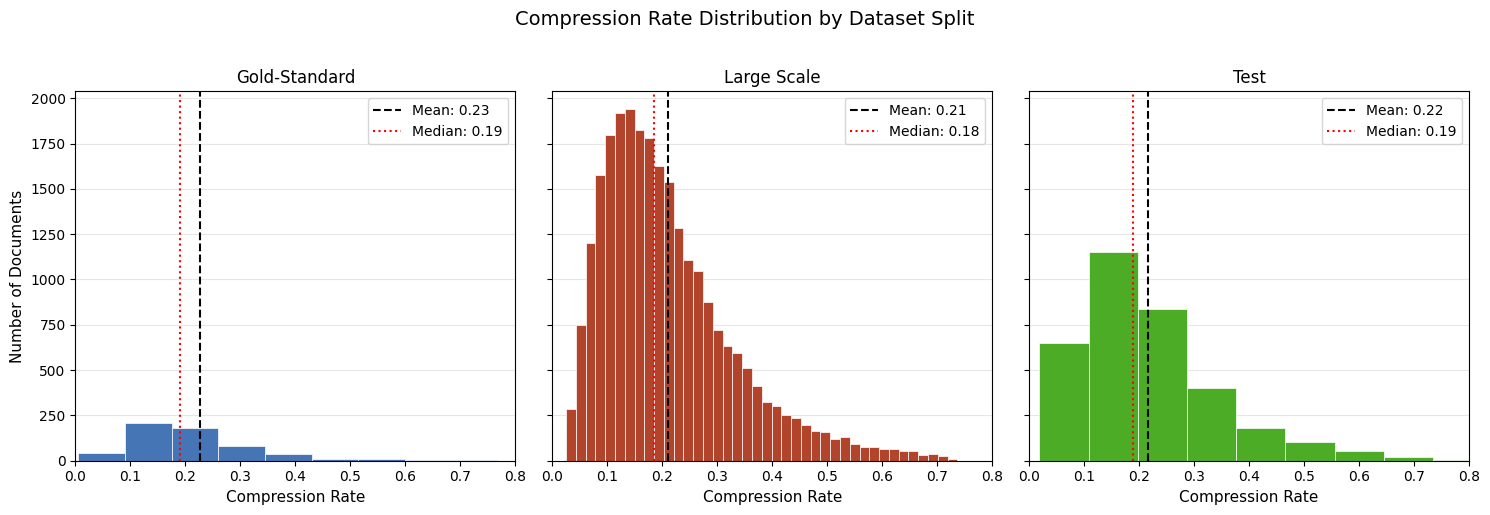

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in zip(axes, datasets):
    ax.hist(df['Compression_Rate'], bins=40, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(df['Compression_Rate'].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df["Compression_Rate"].mean():.2f}')
    ax.axvline(df['Compression_Rate'].median(), color='red', linestyle=':', linewidth=1.5, label=f'Median: {df["Compression_Rate"].median():.2f}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Compression Rate', fontsize=11)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)

axes[0].set_ylabel('Number of Documents', fontsize=11)
fig.suptitle('Compression Rate Distribution by Dataset Split', fontsize=14, y=1.02)
axes[0].set_xlim(0, 0.8)
plt.tight_layout()
plt.show()

### Section 3.3: Word frequency evaluation

[nltk_data] Downloading package stopwords to /home/laptop/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


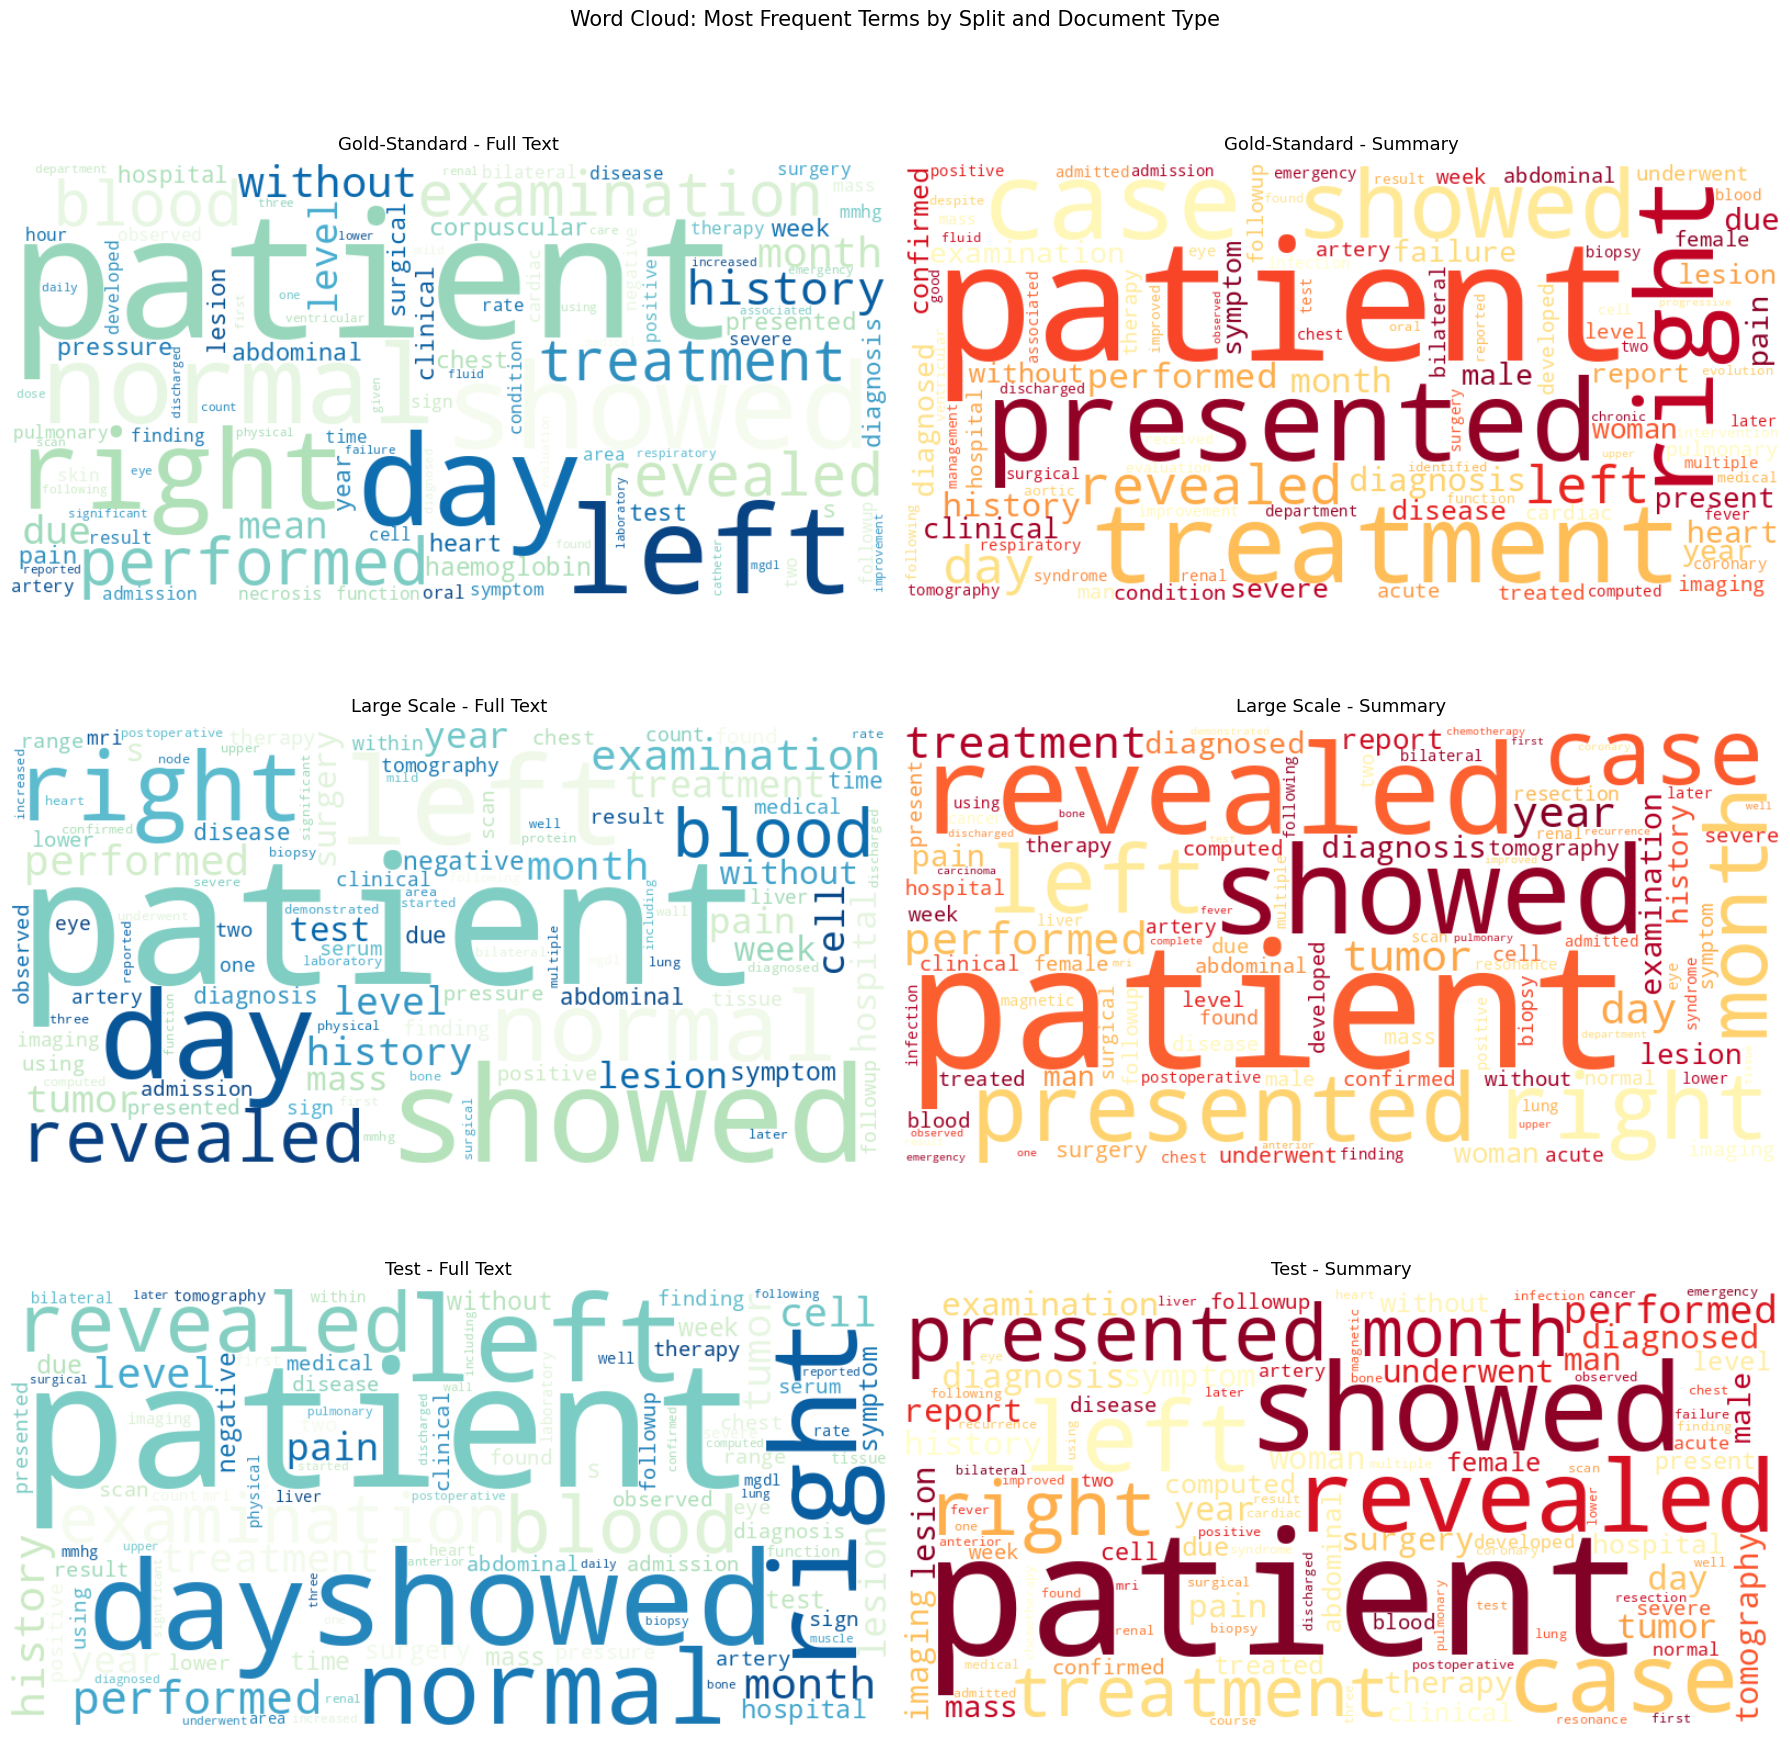

In [19]:
nltk.download('stopwords')

stop_words = set(nltk.corpus.stopwords.words('english'))

def get_clean_text(df, column):
    all_text = ' '.join(df[column].tolist()).lower()
    tokens = all_text.translate(str.maketrans('', '', string.punctuation)).split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

splits = {'Gold-Standard': df_gs, 'Large Scale': df_large, 'Test': df_test}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

for row_idx, (split_name, df) in enumerate(splits.items()):
    for col_idx, (column, label) in enumerate([('Full_Text', 'Full Text'), ('Summary', 'Summary')]):
        clean_text = get_clean_text(df, column)

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='GnBu' if col_idx == 0 else 'YlOrRd',
            max_words=100,
            collocations=False
        ).generate(clean_text)

        ax = axes[row_idx][col_idx]
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{split_name} - {label}', fontsize=13, pad=10)

fig.suptitle('Word Cloud: Most Frequent Terms by Split and Document Type', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Section 3.4: ROUGE-1 metrics

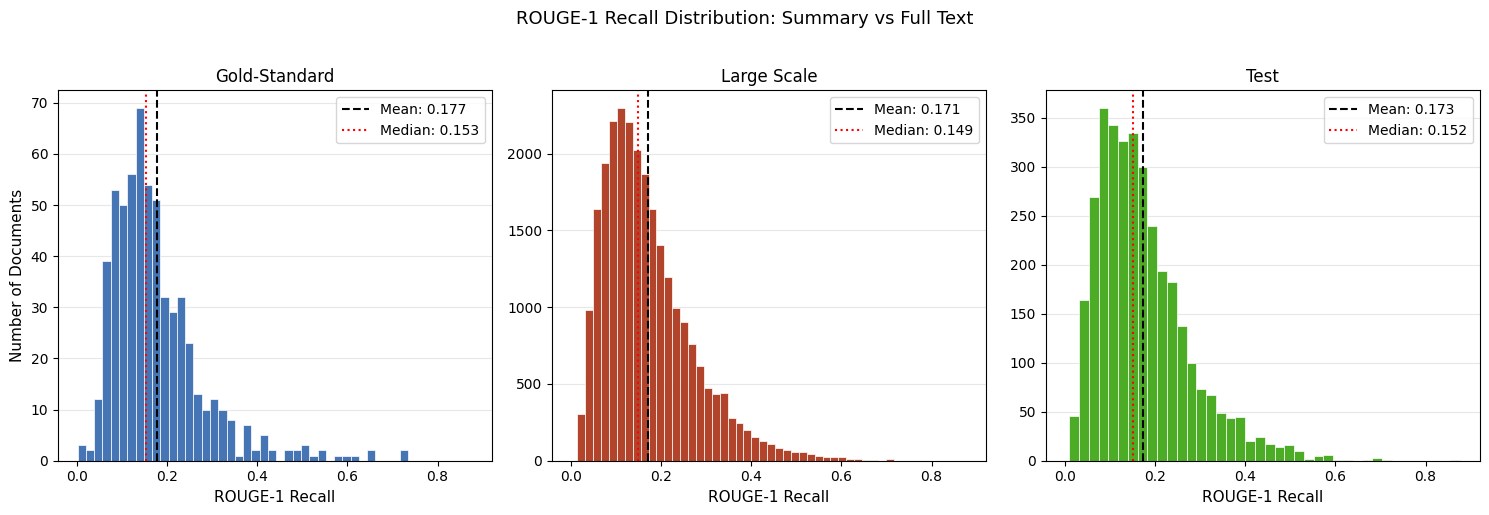

In [20]:
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)

def compute_rouge1_recall(df):
    scores = []
    for _, row in df.iterrows():
        score = scorer.score(row['Full_Text'], row['Summary'])
        scores.append(score['rouge1'].recall)
    return scores

df_gs['ROUGE1_Recall'] = compute_rouge1_recall(df_gs)
df_large['ROUGE1_Recall'] = compute_rouge1_recall(df_large)
df_test['ROUGE1_Recall'] = compute_rouge1_recall(df_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False, sharex=True)

datasets = [
    (df_gs, 'Gold-Standard', '#4575B4'),
    (df_large, 'Large Scale', '#B2442B'),
    (df_test, 'Test', '#4DAC26'),
]

for ax, (df, title, color) in enumerate(datasets):
    axes[ax].hist(df['ROUGE1_Recall'], bins=40, color=color,
                  edgecolor='white', linewidth=0.5)
    axes[ax].axvline(df['ROUGE1_Recall'].mean(), color='black',
                     linestyle='--', linewidth=1.5,
                     label=f'Mean: {df["ROUGE1_Recall"].mean():.3f}')
    axes[ax].axvline(df['ROUGE1_Recall'].median(), color='red',
                     linestyle=':', linewidth=1.5,
                     label=f'Median: {df["ROUGE1_Recall"].median():.3f}')
    axes[ax].set_title(title, fontsize=12)
    axes[ax].set_xlabel('ROUGE-1 Recall', fontsize=11)
    axes[ax].yaxis.grid(True, alpha=0.3)
    axes[ax].set_axisbelow(True)
    axes[ax].legend(fontsize=10)

axes[0].set_ylabel('Number of Documents', fontsize=11)
fig.suptitle('ROUGE-1 Recall Distribution: Summary vs Full Text',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Section 4: Entity extraction

### Section 4.1: Setup

In [21]:

import sys
import warnings
sys.path.append(".")
warnings.filterwarnings("ignore", category=UserWarning, module="spacy")

from utilities.extractor import extract_all

sample_pairs = df_gs.sample(5, random_state=42).reset_index(drop=True)
sample_pairs[["Full_Text", "Summary"]].head()


,Full_Text,Summary
0,A 4-year-old girl was admitted to our hospital...,A 4-year-old girl was admitted to our hospital...
1,A term boy baby with birth weight of 3 kg was ...,We report a newborn baby presented with cyanos...
2,Our patient is a 21-year-old G1P0 female with ...,"The patient is a 21-year-old woman with JLS, s..."
3,A 3-year-old boy with an Ommaya reservoir in h...,A 3-year-old boy with an Ommaya reservoir in t...
4,A 55-year-old female patient with a medical hi...,he present study describes a 55 year-old femal...


### Section 4.2: Side-by-side comparison

In [22]:
def render_comparison(full_text: str, summary: str, sample_idx: int) -> None:
    source_entities = extract_all(full_text)
    summary_entities = extract_all(summary)

    print(f"----------------- Sample {sample_idx} " + "--------" * 60)

    for category in ["numbers", "gender_terms", "medications", "diseases"]:
        source_set = set(source_entities[category])
        summary_set = set(summary_entities[category])
        all_items = sorted(source_set | summary_set)

        if not all_items:
            continue

        print(f"\n  {category.upper()}")
        print(f"  {'FULL_TEXT':<40}{'SUMMARY'}")

        for item in all_items:
            in_source = item in source_set
            in_summary = item in summary_set

            left = item if in_source else "-------------"
            right = item if in_summary else "------------"
            flag = "  ------------" if in_summary and not in_source else ""

            print(f"  {left:<40}{right}{flag}")
    print()


for idx, row in sample_pairs.iterrows():
    render_comparison(row["Full_Text"], row["Summary"], sample_idx=idx + 1)


/home/laptop/Documents/College/Thesis/venv/lib/python3.14/site-packages/spacy/language.py:2235: FutureWarning: Possible set union at position 6328
  deserializers["tokenizer"] = lambda p: self.tokenizer.from_disk(  # type: ignore[union-attr]
/home/laptop/Documents/College/Thesis/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.1.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/laptop/Documents/College/Thesis/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.1.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit

﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Sample 1 ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿

  NUMBERS
  FULL_TEXT                               SUMMARY
  1.0 %                                   ﷿﷿﷿﷿﷿﷿﷿﷿﷿
  37.9 ﷿﷿c                                 ﷿﷿﷿﷿﷿﷿﷿﷿﷿
  4-year-old                              4-year-old
  90.5 %                                  ﷿﷿﷿﷿﷿﷿﷿﷿﷿
  97 %                                    ﷿﷿﷿﷿﷿﷿﷿﷿﷿

  GENDER_TERMS
  FULL_TEXT                               SUMMARY
  female                                  

# Section 5: Entity selection validation

In [23]:
from tqdm.auto import tqdm

from utilities.extractor import extract_all

CATEGORIES = ["numbers", "gender_terms", "medications", "diseases"]

tqdm.pandas(desc="Extracting source entities")
df_gs["src_entities"] = df_gs["Full_Text"].progress_apply(extract_all)
tqdm.pandas(desc="Extracting summary entities")
df_gs["sum_entities"] = df_gs["Summary"].progress_apply(extract_all)

df_gs[["src_entities", "sum_entities"]].head(3)

Extracting source entities:   0%|          | 0/592 [00:00<?, ?it/s]

Extracting summary entities:   0%|          | 0/592 [00:00<?, ?it/s]

,src_entities,sum_entities
0,"{'numbers': ['1.678 ng/ml', '105 mmhg', '11.5 ...","{'numbers': ['49-year-old'], 'gender_terms': [..."
1,"{'numbers': ['29-year-old'], 'gender_terms': [...","{'numbers': ['29-year-old'], 'gender_terms': [..."
2,"{'numbers': ['0.25 ﷿﷿g', '1 mg/kg', '2 mg/kg', ...","{'numbers': ['2 mg/kg', '30.8 %', '37-year-old..."


### Section 5.1: Entity count distribution

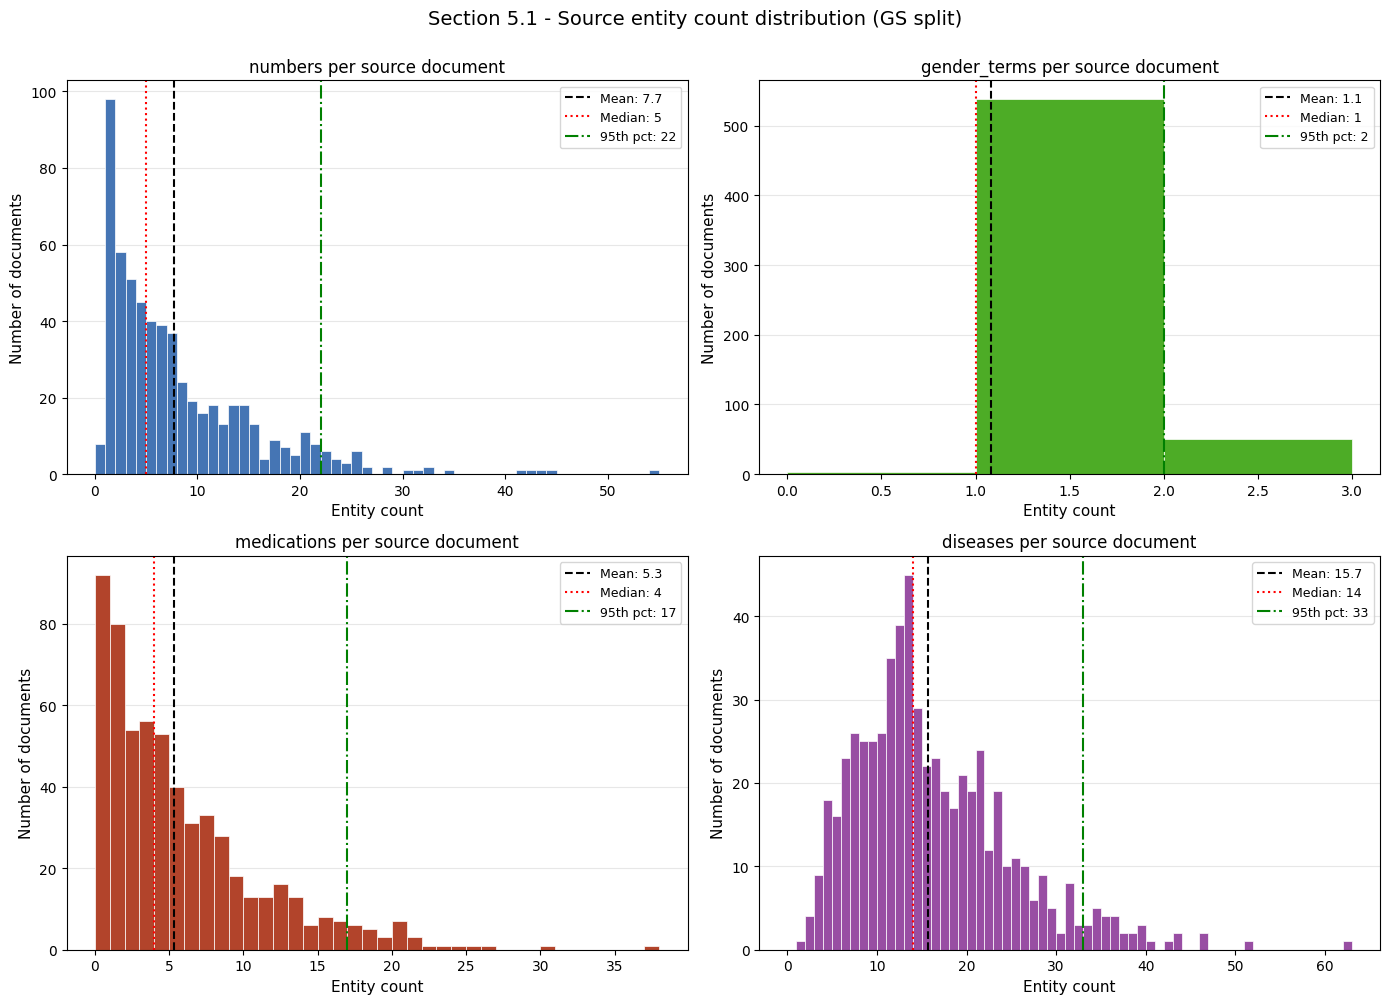

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panel_colors = {'numbers': '#4575B4', 'gender_terms': '#4DAC26',
                'medications': '#B2442B', 'diseases': '#984ea3'}

for ax, category in zip(axes.flat, CATEGORIES):
    counts = df_gs["src_entities"].apply(lambda e: len(e[category]))
    ax.hist(counts, bins=range(0, int(counts.max()) + 2),
            color=panel_colors[category], edgecolor='white', linewidth=0.5)
    ax.axvline(counts.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {counts.mean():.1f}')
    ax.axvline(counts.median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Median: {counts.median():.0f}')
    p95 = counts.quantile(0.95)
    ax.axvline(p95, color='green', linestyle='-.', linewidth=1.5,
               label=f'95th pct: {p95:.0f}')
    ax.set_title(f'{category} per source document', fontsize=12)
    ax.set_xlabel('Entity count', fontsize=11)
    ax.set_ylabel('Number of documents', fontsize=11)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

fig.suptitle('Section 5.1 - Source entity count distribution (GS split)', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

### Section 5.2: Entity retention rate

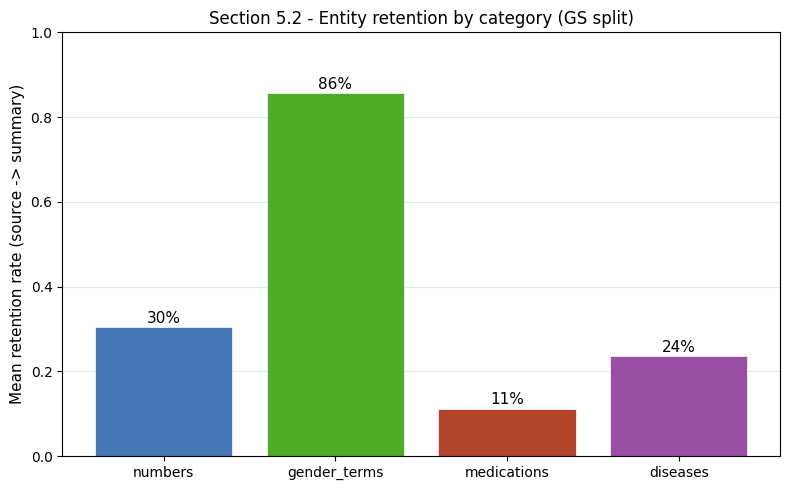

  numbers        retention: 30.5%
  gender_terms   retention: 85.7%
  medications    retention: 11.2%
  diseases       retention: 23.6%


In [25]:
retention = {}
for category in CATEGORIES:
    rates = []
    for _, row in df_gs.iterrows():
        src = set(row["src_entities"][category])
        if not src:
            continue
        summ = set(row["sum_entities"][category])
        rates.append(len(src & summ) / len(src))
    retention[category] = np.mean(rates)

fig, ax = plt.subplots(figsize=(8, 5))
cats = list(retention)
vals = [retention[c] for c in cats]
bars = ax.bar(cats, vals, color=['#4575B4', '#4DAC26', '#B2442B', '#984ea3'],
              edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.0%}', ha='center', fontsize=11)
ax.set_ylabel('Mean retention rate (source -> summary)', fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Section 5.2 - Entity retention by category (GS split)', fontsize=12)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

for category in CATEGORIES:
    print(f"  {category:<14} retention: {retention[category]:.1%}")

### Section 5.3: IDF distribution (diseases)

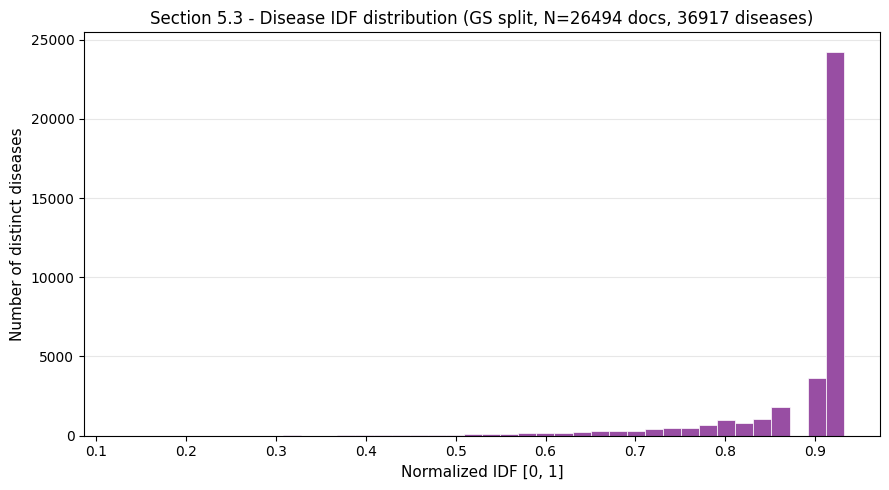

Lowest IDF (most common across documents, least diagnostic):
  IDF 0.127  df=7296  neoplasms
  IDF 0.129  df=7155  pain
  IDF 0.152  df=5629  fever
  IDF 0.163  df=5024  edema
  IDF 0.175  df=4450  hypertensive disease
  IDF 0.177  df=4364  hemorrhage
  IDF 0.197  df=3569  dyspnea
  IDF 0.199  df=3506  communicable diseases
  IDF 0.200  df=3461  malignant neoplasms
  IDF 0.211  df=3092  abdominal pain

Highest IDF (rarest, most diagnostic - must survive into the summary):
  IDF 0.932  df=  1  ipsilateral neck lymphadenopathy
  IDF 0.932  df=  1  shawl﷿﷿﷿s sign) (e) and upper thighs, laterally (holster sign)
  IDF 0.932  df=  1  pjis
  IDF 0.932  df=  1  allofit﷿﷿
  IDF 0.932  df=  1  congenital pneumonia
  IDF 0.932  df=  1  secondary prevention
  IDF 0.932  df=  1  squamous or columnar epithelial lining
  IDF 0.932  df=  1  primary eosinophilic gastrointestinal disease
  IDF 0.932  df=  1  formula milk
  IDF 0.932  df=  1  erosion of the mucous


In [26]:
from utilities.entity_selector import EntitySelector

selector = EntitySelector.load("utilities/idf_weights.json")
idf = selector.normalized_idf
idf_items = sorted(idf.items(), key=lambda kv: kv[1])
idf_vals = [v for _, v in idf_items]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(idf_vals, bins=40, color='#984ea3', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Normalized IDF [0, 1]', fontsize=11)
ax.set_ylabel('Number of distinct diseases', fontsize=11)
ax.set_title(f'Section 5.3 - Disease IDF distribution (GS split, N={selector.n_docs} docs, '
             f'{len(idf)} diseases)', fontsize=12)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("Lowest IDF (most common across documents, least diagnostic):")
for name, val in idf_items[:10]:
    print(f"  IDF {val:.3f}  df={selector.doc_freq[name]:>3}  {name}")

print("\nHighest IDF (rarest, most diagnostic - must survive into the summary):")
for name, val in sorted(idf_items, key=lambda kv: -kv[1])[:10]:
    print(f"  IDF {val:.3f}  df={selector.doc_freq[name]:>3}  {name}")

### Section 5.4: Entity budget analysis

Budget base gen_length = 170 tokens  ->  51 entity-token budget
Documents fully covered by budget: 66/592 (11%)
Mean coverage (all docs):            53%
Mean coverage (overflow docs only):  47%


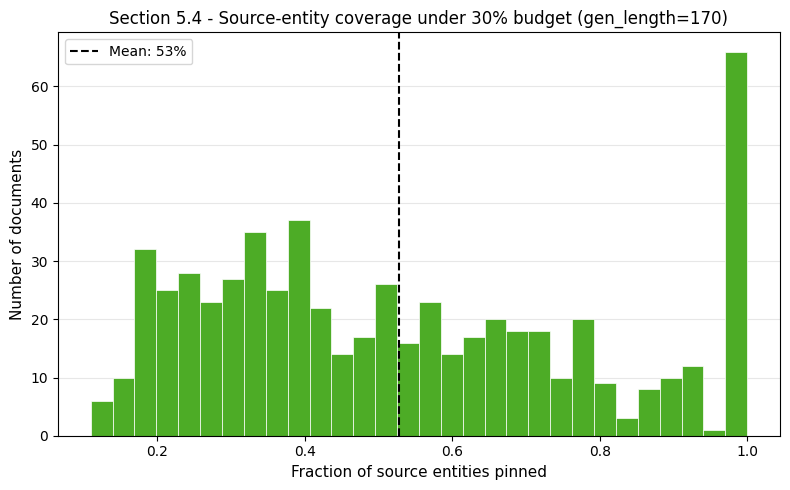

In [27]:
from utilities.entity_selector import EntitySelector

selector = EntitySelector.load("utilities/idf_weights.json")

GEN_LENGTH = 170

full_cover = 0
coverages = []
overflow_coverages = []
for _, row in df_gs.iterrows():
    ents = row["src_entities"]
    total = sum(len(ents[c]) for c in CATEGORIES)
    if total == 0:
        continue
    selected = selector.select(ents, row["Full_Text"], gen_length=GEN_LENGTH, tokenizer=tokenizer)
    cov = len(selected) / total
    coverages.append(cov)
    if len(selected) == total:
        full_cover += 1
    else:
        overflow_coverages.append(cov)

n = len(coverages)
print(f"Budget base gen_length = {GEN_LENGTH} tokens  ->  {int(0.3 * GEN_LENGTH)} entity-token budget")
print(f"Documents fully covered by budget: {full_cover}/{n} ({full_cover / n:.0%})")
print(f"Mean coverage (all docs):            {np.mean(coverages):.0%}")
if overflow_coverages:
    print(f"Mean coverage (overflow docs only):  {np.mean(overflow_coverages):.0%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(coverages, bins=30, color='#4DAC26', edgecolor='white', linewidth=0.5)
ax.axvline(np.mean(coverages), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean: {np.mean(coverages):.0%}')
ax.set_xlabel('Fraction of source entities pinned', fontsize=11)
ax.set_ylabel('Number of documents', fontsize=11)
ax.set_title(f'Section 5.4 - Source-entity coverage under 30% budget (gen_length={GEN_LENGTH})',
             fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()